In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#import cleaned dataset
df = pd.read_csv('cleaned_data.csv')

In [3]:
#Analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        720 non-null    object
 1   company     720 non-null    object
 2   year        720 non-null    int64 
 3   Price       720 non-null    int64 
 4   kms_driven  720 non-null    int64 
 5   fuel_type   720 non-null    object
dtypes: int64(3), object(3)
memory usage: 33.9+ KB


In [4]:
#company wise vehicle count
#yearwise count of vehicles
#fuel type wise count of vehicles
#min, avg, max kms_driven
#price wise vehicle
#kms_driven wise company
#year wise price

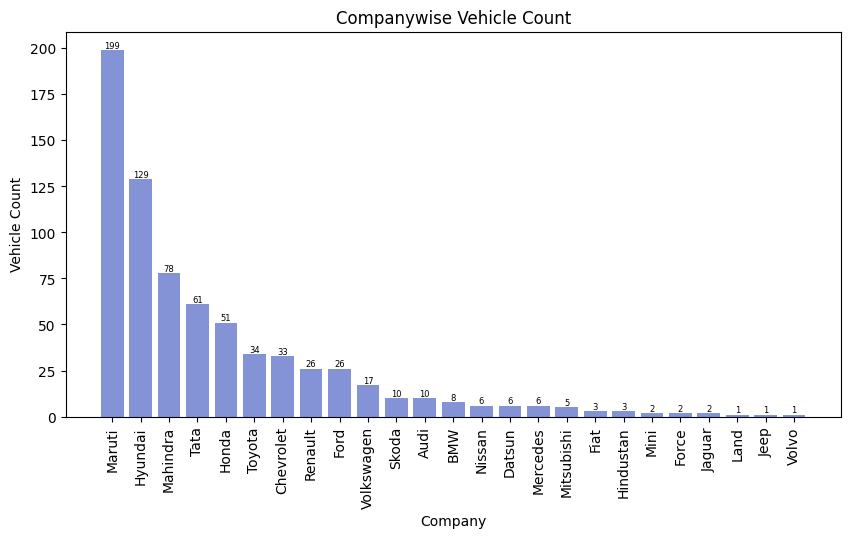

In [24]:
#Companywise Vehicle Count
data = df['company'].value_counts()
plt.figure(figsize=(10,5))
plt.bar(data.index, data.values, color = '#8393d6')
plt.title("Companywise Vehicle Count")
plt.xlabel("Company")
plt.ylabel("Vehicle Count")
plt.xticks(rotation = 90)
for x, y in zip(data.index, data.values):
    plt.text(x, y, y, ha = 'center', va = 'bottom', fontsize = 6)
plt.show()

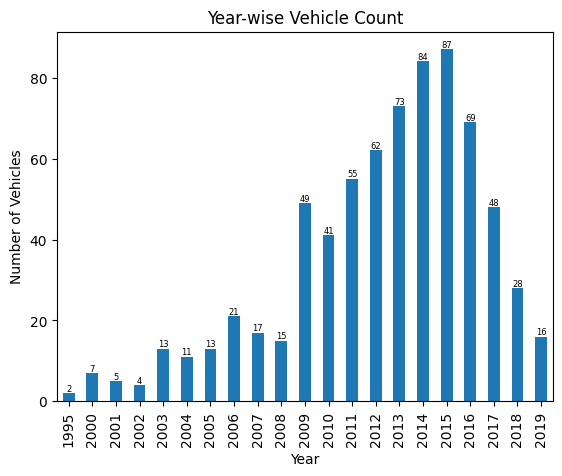

In [35]:
#Yearwise Vehicle Count
ax = df['year'].value_counts().sort_index().plot(kind = 'bar')
ax.bar_label(ax.containers[0], fontsize = 6)
plt.title('Year-wise Vehicle Count')
plt.xlabel('Year')
plt.ylabel('Number of Vehicles')
plt.show()

In [71]:
#fuel type wise count of vehicles
df['fuel_type'].value_counts().plot(kind = 'pie', autopct='%1.1f%%', figsize=(5, 5), startangle=90)
plt.title('Fuel Type Distribution')
plt.ylabel('')  # Remove y-axis label
plt.show()

In [43]:
#kms_driven analyze
min_kms = df['kms_driven'].min()
max_kms = df['kms_driven'].max()
mean_kms = df['kms_driven'].mean()
print("Min Kms:", min_kms)
print("Max Kms:", max_kms)
print("Average Kms:", mean_kms)

Min Kms: 0
Max Kms: 400000
Average Kms: 46787.39722222222


In [47]:
# sorted(df['kms_driven'].unique())
#we will consider vehicles running between 1000 to 200000

In [72]:
#kms_driven wise company
sns.swarmplot(x = 'company', y = 'kms_driven', data = df)
plt.xticks(rotation = 90)
plt.show()

In [51]:
#Price analyze
min_price = df['Price'].min()
max_price = df['Price'].max()
mean_price = df['Price'].mean()
print("Min Price:", min_price)
print("Max Price:", max_price)
print("Average Price:", mean_price)

Min Price: 30000
Max Price: 8500003
Average Price: 402157.38194444444


In [55]:
# pd.set_option('display.max_rows', None)
#df['Price'].value_counts().sort_index()
#we will consider vehicles Price between 70000 to 2000000

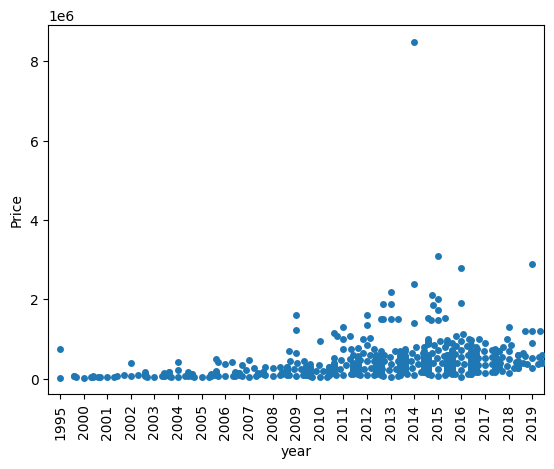

In [50]:
#year wise price
sns.swarmplot(x = 'year', y = 'Price', data = df)
plt.xticks(rotation = 90)
plt.show()

#company wise price
sns.swarmplot(x = 'company', y = 'Price', data = df)
plt.xticks(rotation = 90)
plt.show()

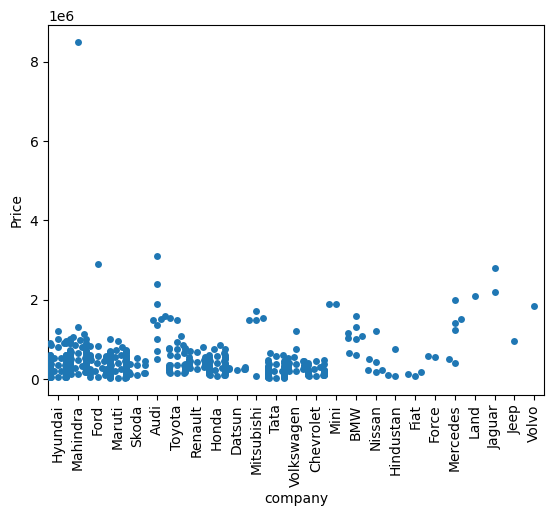

In [61]:
#We will consider running between 1000 to 200000
#We will consider Price between 70000 to 2000000
#We will consider only Petrol and Diesel
df = df[(df['kms_driven'] >= 1000) & (df['kms_driven'] <= 200000)]
df = df[(df['Price'] >= 70000) & (df['Price'] <= 2000000)]
df = df[df['fuel_type'] != 'LPG']

In [70]:
df.to_csv('final_data.csv', index = False)